# CSI4142 - Fundamentals of Data Science
# Assignment 1: Exploratory Data Analysis

**Student 1:** Peter Bou-Farah - 300295193  
**Student 2:** Martin Patrouchev - 300286634

---
# DATASET 1: Heart Failure Prediction Dataset
---

## 1. Introduction

### Goal of the Analysis
This report presents an exploratory data analysis (EDA) of two datasets to uncover meaningful insights through statistical analysis and visualization techniques. We examine central tendency measures, dispersion metrics, and relationships between variables using both univariate and bivariate analysis methods.

### Target Audience
This analysis is intended for **healthcare professionals and medical researchers** who are interested in understanding the factors that contribute to heart disease, as well as **financial analysts and investors** interested in understanding S&P 500 company characteristics. The insights derived can help clinicians identify high-risk patients and inform preventive care strategies, while also helping investors understand sector composition and valuation patterns.

---
## 2. Setup and Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


warnings.filterwarnings('ignore')

## 3. Dataset 1 Description

### Overview
- **Dataset Name:** Heart Failure Prediction Dataset
- **Author:** fedesoriano (Kaggle)
- **Source:** [GitHub - Heart Failure Prediction Dataset](https://raw.githubusercontent.com/xpy-10/DataSet/refs/heads/main/heart.csv) | [Kaggle - Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)
- **Purpose:** This dataset was created to predict heart disease based on clinical and demographic features. It combines five existing heart disease datasets (Cleveland, Hungarian, Switzerland, Long Beach VA, and Stalog).

### Shape
- **Rows:** 918 patients
- **Columns:** 12 features

### Features Description

| Feature | Type | Description |
|---------|------|-------------|
| Age | Numerical | Age of the patient in years |
| Sex | Categorical | Sex of the patient (M: Male, F: Female) |
| ChestPainType | Categorical | Type of chest pain (TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic) |
| RestingBP | Numerical | Resting blood pressure in mm Hg |
| Cholesterol | Numerical | Serum cholesterol in mg/dl |
| FastingBS | Categorical | Fasting blood sugar > 120 mg/dl (1: True, 0: False) |
| RestingECG | Categorical | Resting electrocardiogram results (Normal, ST, LVH) |
| MaxHR | Numerical | Maximum heart rate achieved |
| ExerciseAngina | Categorical | Exercise-induced angina (Y: Yes, N: No) |
| Oldpeak | Numerical | ST depression induced by exercise relative to rest |
| ST_Slope | Categorical | Slope of the peak exercise ST segment (Up, Flat, Down) |
| HeartDisease | Categorical (Target) | Heart disease diagnosis (1: Yes, 0: No) |

### Data Quality Notes
- **Missing Values:** The dataset has no missing values in the traditional sense, but contains 0 values in Cholesterol (172 rows) and RestingBP (1 row) which may represent missing/unmeasured data.
- **Redundancy:** No redundant features detected; each feature captures a distinct clinical measurement.

## 4. Loading Dataset 1

In [20]:
# Load the Fedesoriano Heart Failure Prediction dataset from GitHub
url_heart = "https://raw.githubusercontent.com/xpy-10/DataSet/refs/heads/main/heart.csv"
df_heart = pd.read_csv(url_heart)

# Display basic information
print("Dataset Shape:", df_heart.shape)
print("\nFirst 5 rows:")
df_heart.head()

Dataset Shape: (918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [21]:
# Dataset information and data types
print("Dataset Info:")
print("=" * 50)
df_heart.info()
print("\n" + "=" * 50)
print("\nStatistical Summary (Numerical Features):")
df_heart.describe()

Dataset Info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Statistical Summary (Numerical Features):


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [22]:
# Check for missing values and data quality
print("Missing Values:")
print(df_heart.isnull().sum())
print("\nZero values in Cholesterol:", (df_heart['Cholesterol'] == 0).sum())
print("Zero values in RestingBP:", (df_heart['RestingBP'] == 0).sum())

Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zero values in Cholesterol: 172
Zero values in RestingBP: 1


---
## 5. Dataset 1 Insights

The following section presents 10 insights derived from exploratory data analysis of the Heart Failure Prediction dataset. Each insight includes a clear statement, supporting visualization, analysis type description, and reproducible code.

### Insight 1 (r1): Age Distribution Shows Most Patients Are Middle-Aged to Elderly

**Insight:** The majority of patients in the dataset are between 50 and 60 years old, with the distribution showing a slight left skew indicating fewer younger patients.

**Analysis type:** Univariate, numerical - histogram for dispersion of a numerical variable.

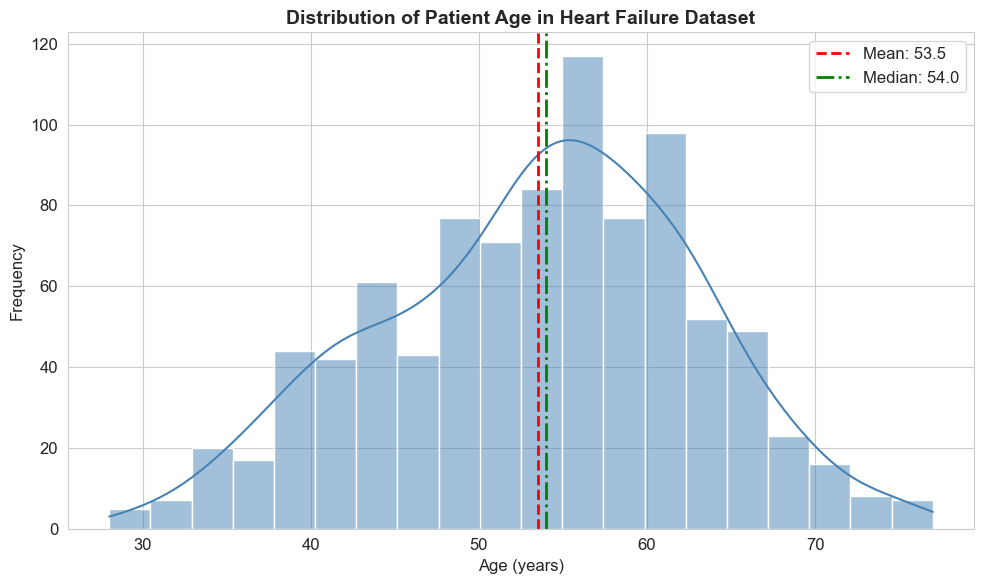

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram with KDE
sns.histplot(data=df_heart, x='Age', bins=20, kde=True, color='steelblue', ax=ax)

# Add mean and median lines
mean_age = df_heart['Age'].mean()
median_age = df_heart['Age'].median()
ax.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')
ax.axvline(median_age, color='green', linestyle='-.', linewidth=2, label=f'Median: {median_age:.1f}')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Patient Age in Heart Failure Dataset', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

### Insight 2 (r5): Males Have Higher Heart Disease Prevalence Than Females

**Insight:** Among males, 63% have heart disease, while only 26% of females have heart disease, indicating a significant gender disparity in heart disease occurrence within this dataset.

**Analysis type:** Bivariate, categorical/categorical - comparing two categories with 2 values.

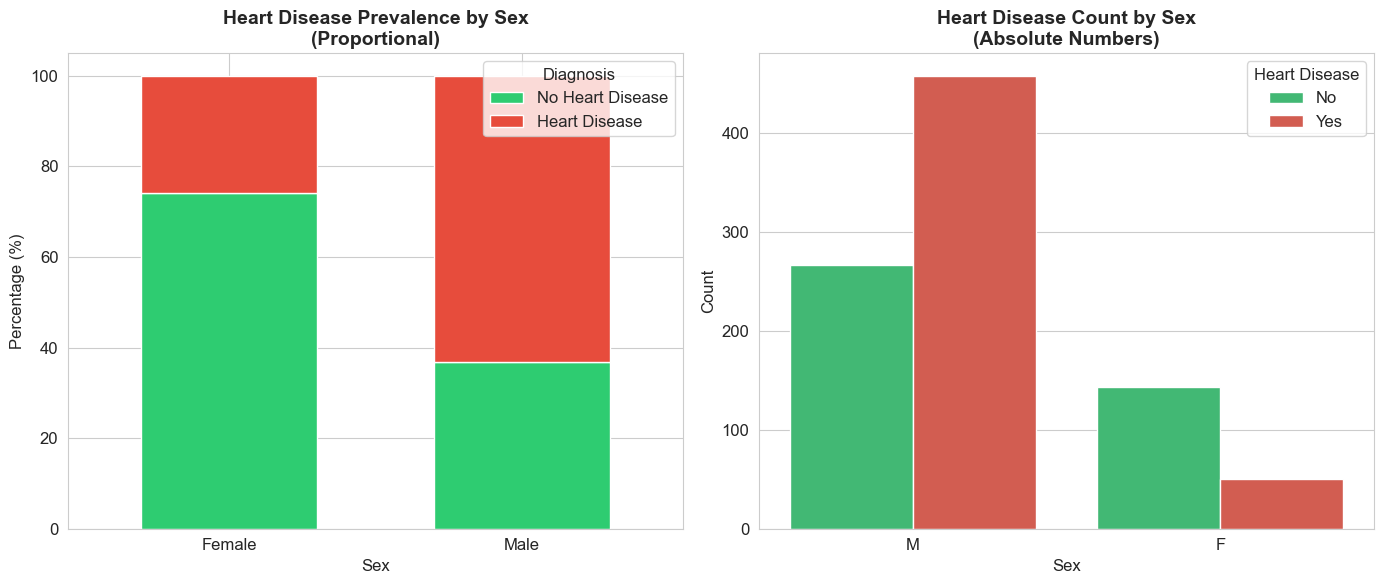

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar chart
cross_tab = pd.crosstab(df_heart['Sex'], df_heart['HeartDisease'], normalize='index') * 100
cross_tab.columns = ['No Heart Disease', 'Heart Disease']
cross_tab.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[0], width=0.6)
axes[0].set_xlabel('Sex', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].set_title('Heart Disease Prevalence by Sex\n(Proportional)', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0].legend(title='Diagnosis')

# Grouped bar chart for counts
sns.countplot(data=df_heart, x='Sex', hue='HeartDisease', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Heart Disease Count by Sex\n(Absolute Numbers)', fontsize=14, fontweight='bold')
axes[1].legend(title='Heart Disease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

### Insight 3 (r4): Maximum Heart Rate Distribution Differs Significantly Between Heart Disease Outcomes

**Insight:** Patients with heart disease have a notably lower maximum heart rate (mean ~130 bpm) compared to patients without heart disease (mean ~158 bpm), suggesting MaxHR is a strong discriminating feature.

**Analysis type:** Bivariate, numerical/categorical - numerical variable distribution by categorical variable values.

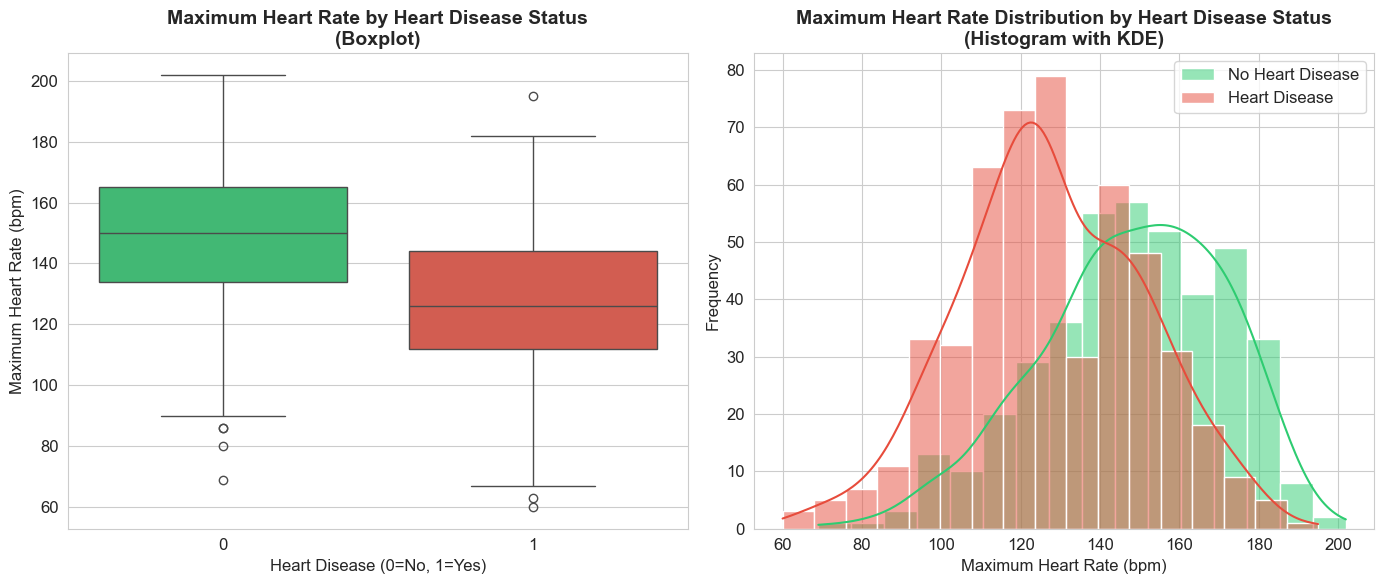

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(data=df_heart, x='HeartDisease', y='MaxHR', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_xlabel('Heart Disease (0=No, 1=Yes)', fontsize=12)
axes[0].set_ylabel('Maximum Heart Rate (bpm)', fontsize=12)
axes[0].set_title('Maximum Heart Rate by Heart Disease Status\n(Boxplot)', fontsize=14, fontweight='bold')

# Histogram with KDE overlay
for hd, color, label in [(0, '#2ecc71', 'No Heart Disease'), (1, '#e74c3c', 'Heart Disease')]:
    subset = df_heart[df_heart['HeartDisease'] == hd]['MaxHR']
    sns.histplot(subset, kde=True, color=color, alpha=0.5, label=label, ax=axes[1])

axes[1].set_xlabel('Maximum Heart Rate (bpm)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Maximum Heart Rate Distribution by Heart Disease Status\n(Histogram with KDE)', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### Insight 4 (r2): Chest Pain Types Are Unevenly Distributed with Asymptomatic Being Most Common

**Insight:** Asymptomatic (ASY) chest pain is the most prevalent type, accounting for over 50% of cases, while Typical Angina (TA) is the least common.

**Analysis type:** Univariate, categorical - countplot for a category with multiple values.

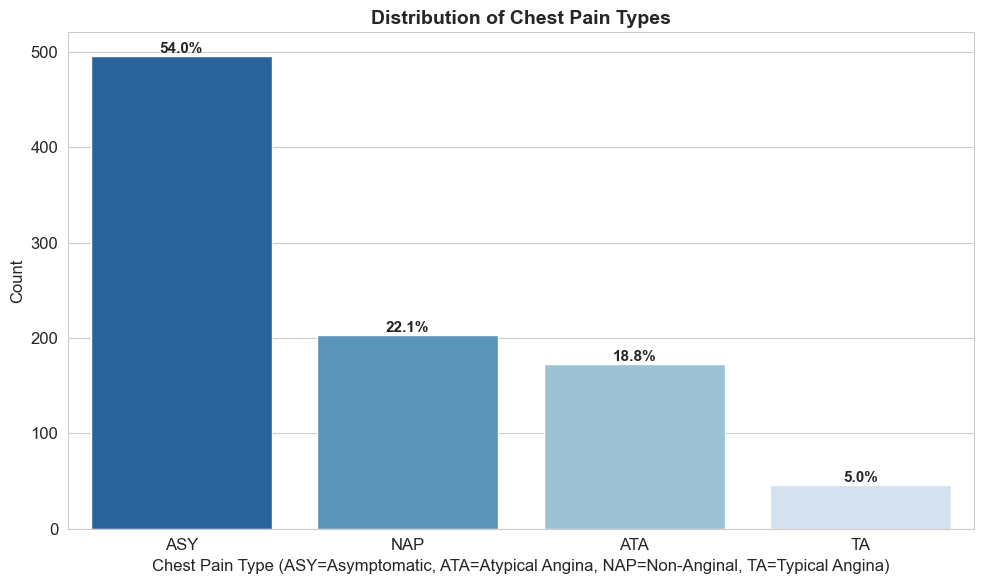

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

chest_pain_order = df_heart['ChestPainType'].value_counts().index
colors = sns.color_palette('Blues_r', n_colors=4)
sns.countplot(data=df_heart, x='ChestPainType', order=chest_pain_order, palette=colors, ax=ax)

total = len(df_heart)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel("Chest Pain Type (ASY=Asymptomatic, ATA=Atypical Angina, NAP=Non-Anginal, TA=Typical Angina)")
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Chest Pain Types', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Insight 5 (r8): Maximum Heart Rate and Oldpeak Show Moderate Negative Correlation

**Insight:** There is a moderate negative correlation (r = -0.38) between MaxHR and Oldpeak, indicating that patients with lower maximum heart rates tend to have higher ST depression values.

**Analysis type:** Bivariate, numerical/numerical - scatterplot to highlight correlation.

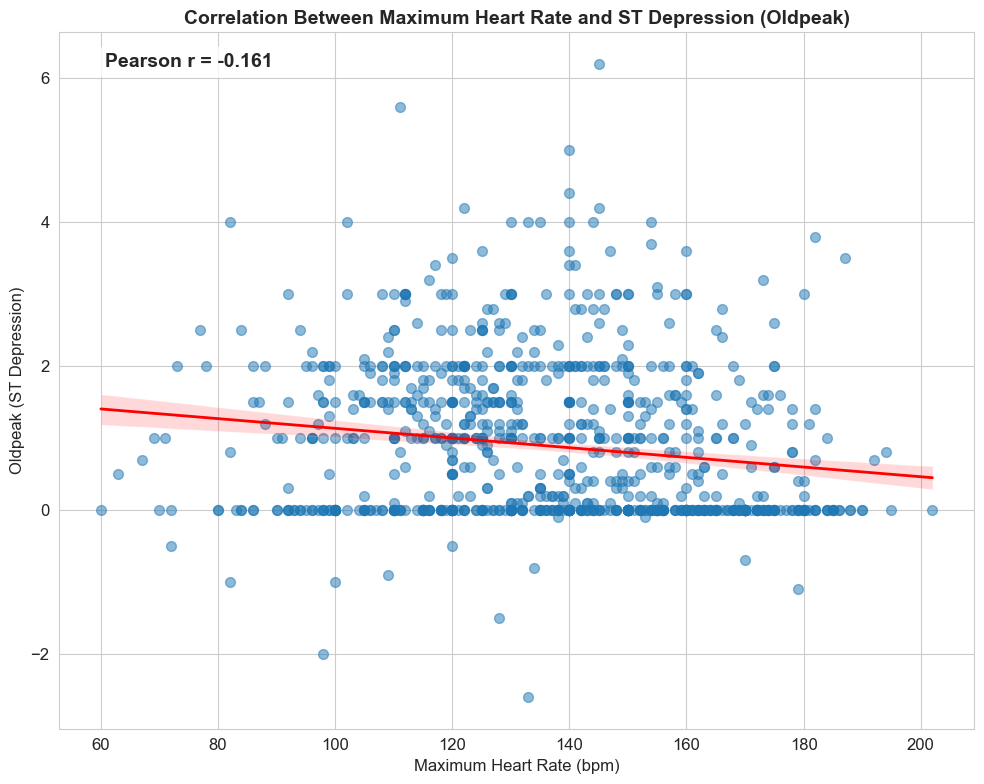

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))

# Scatterplot with regression line
sns.regplot(data=df_heart, x='MaxHR', y='Oldpeak', scatter_kws={'alpha': 0.5, 's': 50}, 
            line_kws={'color': 'red', 'linewidth': 2}, ax=ax)

# Calculate correlation
correlation = df_heart['MaxHR'].corr(df_heart['Oldpeak'])

# Add correlation annotation
ax.annotate(f'Pearson r = {correlation:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
            fontsize=14, fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Maximum Heart Rate (bpm)', fontsize=12)
ax.set_ylabel('Oldpeak (ST Depression)', fontsize=12)
ax.set_title('Correlation Between Maximum Heart Rate and ST Depression (Oldpeak)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The scatterplot reveals a moderate negative relationship - as maximum heart rate decreases, the ST depression value tends to increase. This aligns with the clinical understanding that lower exercise capacity (reflected in lower MaxHR) is associated with more pronounced cardiac stress indicators.

### Insight 6 (r3): Patients Can Be Grouped into Cardiovascular Risk Categories Based on Cholesterol Levels

**Insight:** When grouping cholesterol into clinical categories (Desirable <200, Borderline 200-239, High >=240), over 40% of patients fall into the high-risk category, indicating a population with elevated cardiovascular risk.

**Analysis type:** Univariate, categorical - grouped-data countplot with grouping explanation.

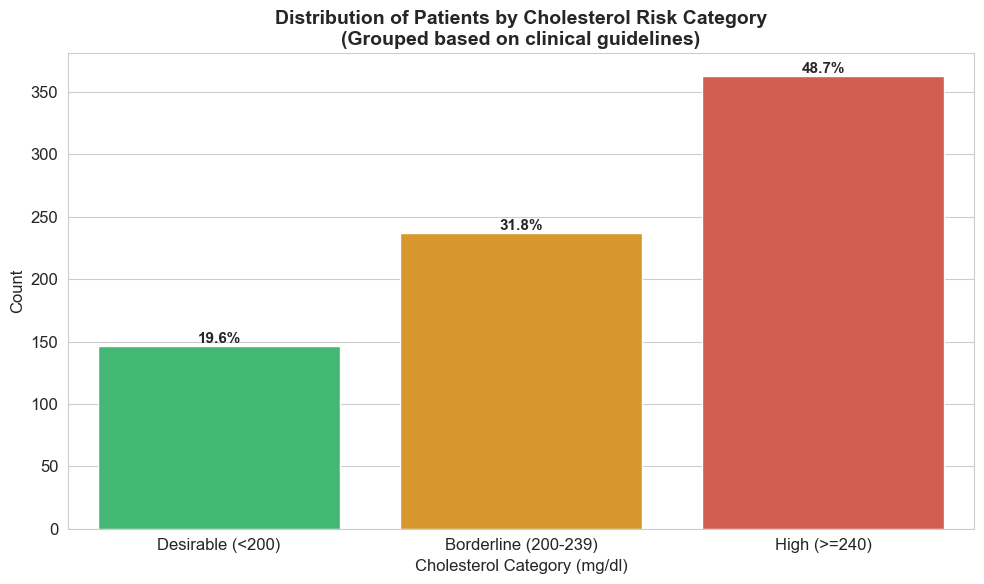

In [28]:
# Filter out zero cholesterol values (likely missing data)
df_chol = df_heart[df_heart['Cholesterol'] > 0].copy()

# Create cholesterol groups based on medical guidelines
def categorize_cholesterol(chol):
    if chol < 200:
        return 'Desirable (<200)'
    elif chol < 240:
        return 'Borderline (200-239)'
    else:
        return 'High (>=240)'

df_chol['Cholesterol_Group'] = df_chol['Cholesterol'].apply(categorize_cholesterol)

# Create countplot
fig, ax = plt.subplots(figsize=(10, 6))
group_order = ['Desirable (<200)', 'Borderline (200-239)', 'High (>=240)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
sns.countplot(data=df_chol, x='Cholesterol_Group', order=group_order, palette=colors, ax=ax)

# Add percentage labels
total = len(df_chol)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Cholesterol Category (mg/dl)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Patients by Cholesterol Risk Category\n(Grouped based on clinical guidelines)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Insight 7 (r6): ST Slope Pattern Shows Strong Association with Heart Disease Diagnosis

**Insight:** Patients with a Flat ST slope have the highest heart disease rate (83%), followed by Down slope (78%), while Up slope patients have the lowest rate (20%), ordered from lowest to highest risk.

**Analysis type:** Bivariate, categorical/categorical - comparing categories with more than 2 values, ordered.

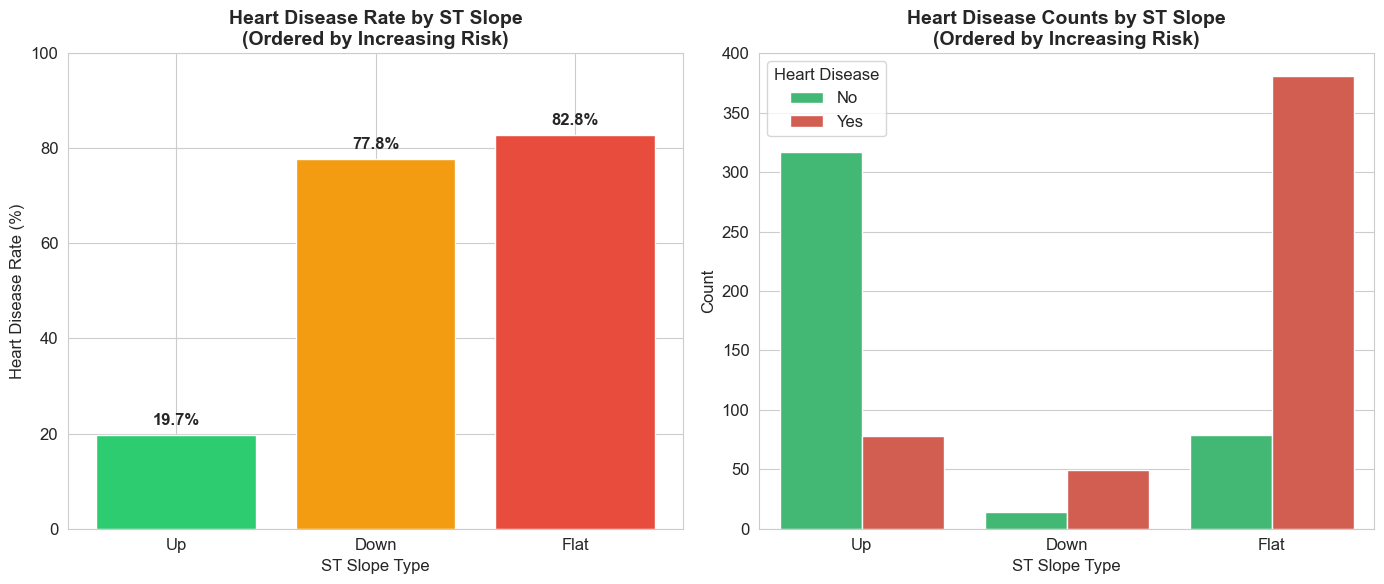

In [29]:
# Calculate heart disease rate by ST_Slope and order by rate
st_slope_rates = df_heart.groupby('ST_Slope')['HeartDisease'].mean().sort_values()
ordered_slopes = st_slope_rates.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart of heart disease rate (ordered by rate)
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green to red gradient
bars = axes[0].bar(ordered_slopes, st_slope_rates.values * 100, color=colors)
axes[0].set_xlabel('ST Slope Type', fontsize=12)
axes[0].set_ylabel('Heart Disease Rate (%)', fontsize=12)
axes[0].set_title('Heart Disease Rate by ST Slope\n(Ordered by Increasing Risk)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 100)

# Add percentage labels on bars
for bar, rate in zip(bars, st_slope_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{rate*100:.1f}%', ha='center', fontweight='bold')

# Countplot with order
sns.countplot(data=df_heart, x='ST_Slope', hue='HeartDisease', order=ordered_slopes, 
              palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_xlabel('ST Slope Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Heart Disease Counts by ST Slope\n(Ordered by Increasing Risk)', fontsize=14, fontweight='bold')
axes[1].legend(title='Heart Disease', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

### Insight 8 (r7): Heart Disease Prevalence Increases Substantially with Age Groups

**Insight:** When patients are grouped into age bins (Young <40, Middle 40-54, Senior 55-64, Elderly 65+), heart disease prevalence increases from 25% in young patients to 67% in elderly patients.

**Analysis type:** Bivariate, categorical/numerical - categorical variable distribution among bins of numerical feature.

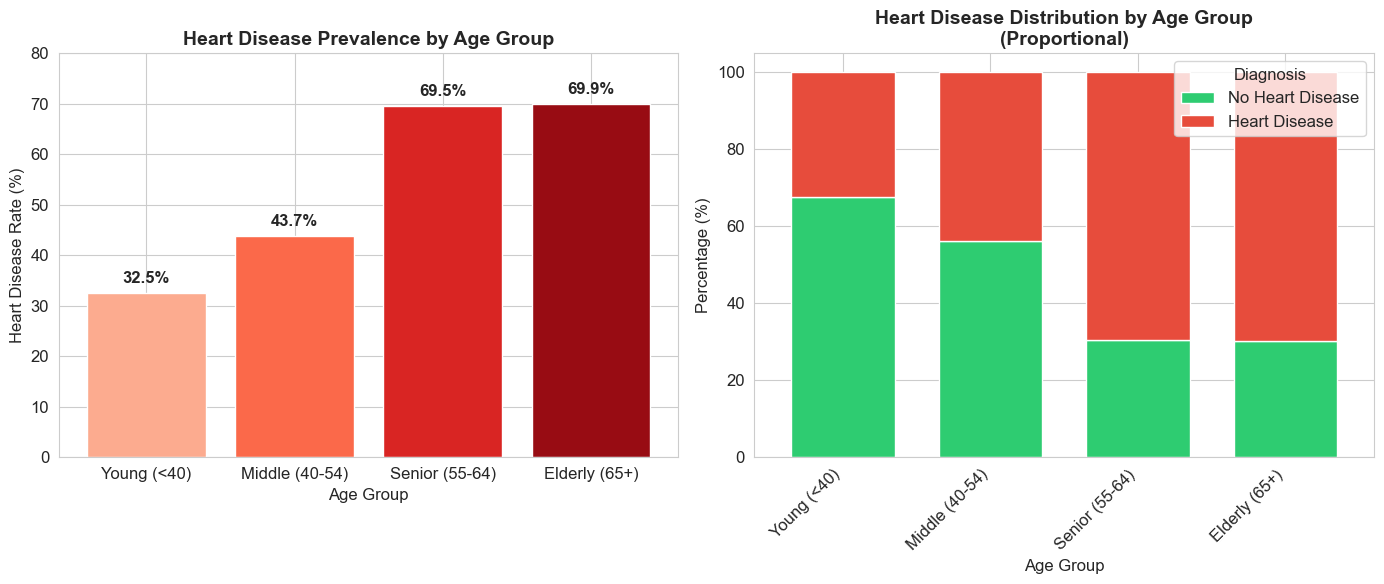

In [30]:
# Create age bins with specific values
age_bins = [0, 40, 55, 65, 100]
age_labels = ['Young (<40)', 'Middle (40-54)', 'Senior (55-64)', 'Elderly (65+)']
df_heart['Age_Group'] = pd.cut(df_heart['Age'], bins=age_bins, labels=age_labels, right=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heart disease rate by age group
age_group_rates = df_heart.groupby('Age_Group', observed=True)['HeartDisease'].mean() * 100
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(age_labels)))
bars = axes[0].bar(age_labels, age_group_rates.values, color=colors)
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Heart Disease Rate (%)', fontsize=12)
axes[0].set_title('Heart Disease Prevalence by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 80)

# Add percentage labels
for bar, rate in zip(bars, age_group_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{rate:.1f}%', ha='center', fontweight='bold')

# Stacked bar chart
cross_tab_age = pd.crosstab(df_heart['Age_Group'], df_heart['HeartDisease'], normalize='index') * 100
cross_tab_age.columns = ['No Heart Disease', 'Heart Disease']
cross_tab_age.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1], width=0.7)
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Heart Disease Distribution by Age Group\n(Proportional)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(age_labels, rotation=45, ha='right')
axes[1].legend(title='Diagnosis')

plt.tight_layout()
plt.show()

### Insight 9 - Resting Blood Pressure Distribution

**Insight:** Most patients have resting blood pressure between 120 and 140 mm Hg, with some outliers showing readings above 170 mm Hg indicating severe hypertension.

**Analysis type:** Univariate, numerical - boxplot for visualization of dispersion.

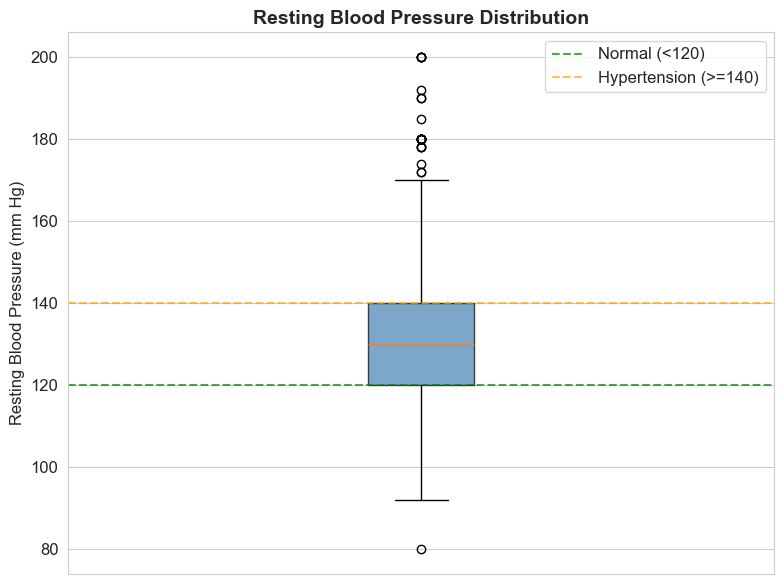

In [31]:
# Filter out 0 values (likely missing data)
df_bp = df_heart[df_heart['RestingBP'] > 0]

fig, ax = plt.subplots(figsize=(8, 6))

# Create boxplot
bp = ax.boxplot(df_bp['RestingBP'], patch_artist=True, vert=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)

# Add reference lines for clinical BP thresholds
ax.axhline(y=120, color='green', linestyle='--', alpha=0.7, label='Normal (<120)')
ax.axhline(y=140, color='orange', linestyle='--', alpha=0.7, label='Hypertension (>=140)')

ax.set_ylabel('Resting Blood Pressure (mm Hg)', fontsize=12)
ax.set_title('Resting Blood Pressure Distribution', fontsize=14, fontweight='bold')
ax.set_xticks([])
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Insight 10 - Exercise-Induced Angina is a Strong Predictor of Heart Disease

**Insight:** Patients with exercise-induced angina have an 85% heart disease rate compared to only 34% for those without, making this binary feature one of the strongest predictors in the dataset.

**Analysis type:** Bivariate, categorical/categorical - comparing two categories with 2 values.

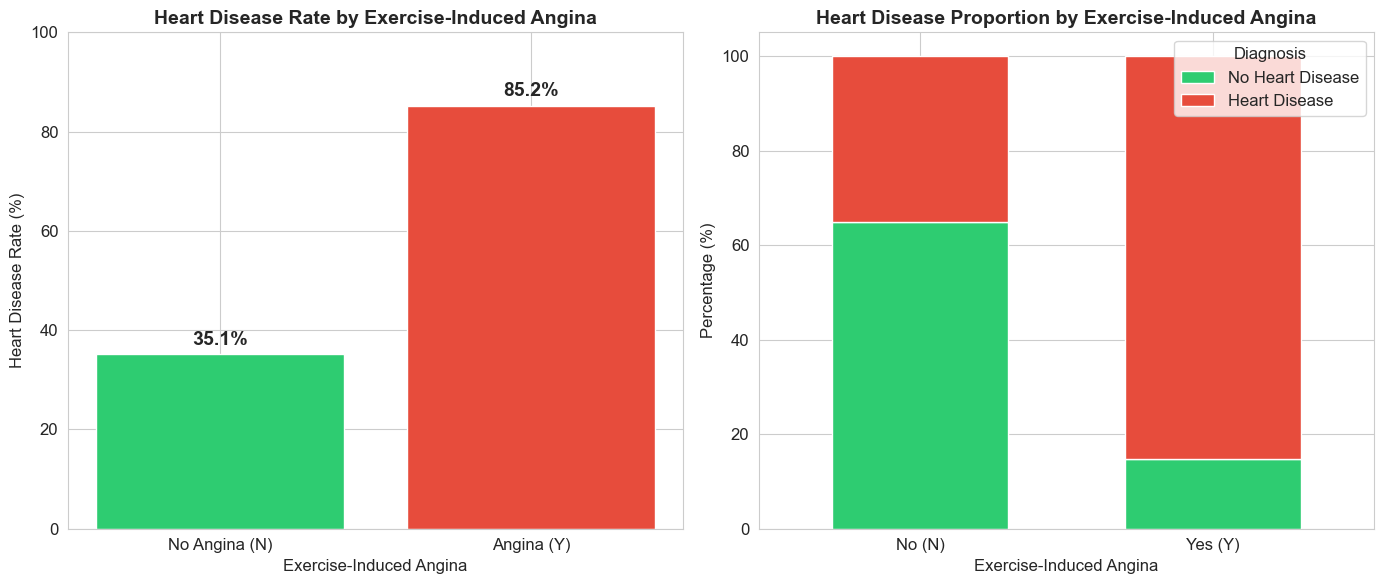

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calculate rates
angina_rates = df_heart.groupby('ExerciseAngina')['HeartDisease'].mean() * 100

# Bar chart of heart disease rate
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['No Angina (N)', 'Angina (Y)'], angina_rates.values, color=colors)
axes[0].set_xlabel('Exercise-Induced Angina', fontsize=12)
axes[0].set_ylabel('Heart Disease Rate (%)', fontsize=12)
axes[0].set_title('Heart Disease Rate by Exercise-Induced Angina', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 100)

# Add percentage labels
for bar, rate in zip(bars, angina_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=14)

# Mosaic-style visualization using stacked bars
cross_tab_angina = pd.crosstab(df_heart['ExerciseAngina'], df_heart['HeartDisease'], normalize='index') * 100
cross_tab_angina.columns = ['No Heart Disease', 'Heart Disease']
cross_tab_angina.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1], width=0.6)
axes[1].set_xlabel('Exercise-Induced Angina', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Heart Disease Proportion by Exercise-Induced Angina', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No (N)', 'Yes (Y)'], rotation=0)
axes[1].legend(title='Diagnosis')

plt.tight_layout()
plt.show()

---
# DATASET 2: S&P 500 Constituents Financials
---

## Introduction
This notebook presents an exploratory data analysis (EDA) of the S&P 500 Constituents Financials dataset. We summarize central tendency and dispersion, and use univariate and bivariate visualizations to uncover insights about sectors, valuation, and financial metrics.

This data set would be great for analysts, investors, or students interested in understanding the composition and financial characteristics of S&P 500 companies.

## 6. Dataset 2 Description

### Overview
- **Name:** S&P 500 Constituents Financials  
- **Source:** [GitHub - s-and-p-500-companies-financials](https://github.com/datasets/s-and-p-500-companies-financials)  
- **Purpose:** Financial and sector data for S&P 500 index constituents (valuation, earnings, dividends, market cap).

### Shape
- **Rows:** 503 companies (one per company)
- **Columns:** 14 features

### Features Description

| Feature | Type | Description |
|--------|------|-------------|
| Symbol | Categorical | Stock ticker |
| Name | Categorical | Company name |
| Sector | Categorical | Industry sector (e.g. Biotechnology, Health Care) |
| Price | Numerical | Stock price |
| Price/Earnings | Numerical | P/E ratio |
| Dividend Yield | Numerical | Dividend yield (decimal) |
| Earnings/Share | Numerical | EPS |
| 52 Week Low / High | Numerical | 52-week price range |
| Market Cap | Numerical | Market capitalization ($) |
| EBITDA | Numerical | Earnings before interest, taxes, depreciation, amortization ($) |
| Price/Sales, Price/Book | Numerical | Valuation ratios |

## 7. Loading Dataset 2

In [33]:
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies-financials/main/data/constituents-financials.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (503, 14)


,Symbol,Name,Sector,Price,Price/Earnings,Dividend Yield,Earnings/Share,52 Week Low,52 Week High,Market Cap,EBITDA,Price/Sales,Price/Book,SEC Filings
0,MMM,3M,Industrial Conglomerates,152.20,21.286713,0.0199,7.15,75.652176,155.00,8.329418e+10,8.117000e+09,2.552062,17.855467,http://www.sec.gov/cgi-bin/browse-edgar?action...
1,AOS,A. O. Smith,Building Products,67.30,18.539946,0.0196,3.63,66.760000,92.45,9.758165e+09,8.091000e+08,2.506078,5.091157,http://www.sec.gov/cgi-bin/browse-edgar?action...
2,ABT,Abbott Laboratories,Health Care Equipment,127.93,16.744764,0.0202,7.64,99.710000,129.85,2.218895e+11,1.082500e+10,5.383446,5.575749,http://www.sec.gov/cgi-bin/browse-edgar?action...
3,ABBV,AbbVie,Biotechnology,183.90,64.300700,0.0373,2.86,153.580000,207.32,3.249770e+11,2.563000e+10,5.851963,53.882210,http://www.sec.gov/cgi-bin/browse-edgar?action...
4,ACN,Accenture,IT Consulting & Other Services,384.95,32.294464,0.0170,11.92,278.690000,387.51,2.407785e+11,1.106591e+10,3.710195,8.508687,http://www.sec.gov/cgi-bin/browse-edgar?action...


---
## 8. Dataset 2 Insights

The following section presents 10 insights derived from exploratory data analysis of the S&P 500 Constituents Financials dataset.

### Insight 1 (r1): Histogram of Price/Earnings

**Insight:** P/E ratios are right-skewed; most S&P 500 constituents have P/E between about 10 and 30, with a long tail of higher valuations (i.e., few companies have extremely high P/E ratios compared to median).

**Analysis type:** Univariate, numerical - histogram for dispersion of a numerical variable.

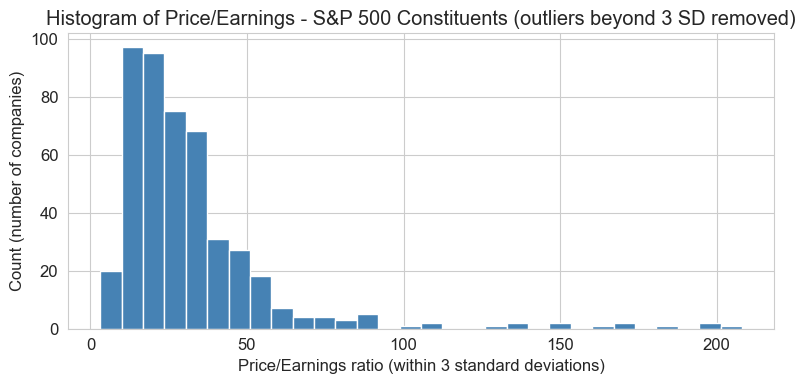

In [34]:
# For visualization purposes, we remove outliers beyond 3 standard deviations
pe = df["Price/Earnings"]
mean_pe = pe.mean()
std_pe = pe.std()
pe_clean = pe[(pe > mean_pe - 3 * std_pe) & (pe < mean_pe + 3 * std_pe)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pe_clean, bins=30, edgecolor="white", color="steelblue")
ax.set_xlabel("Price/Earnings ratio (within 3 standard deviations)")
ax.set_ylabel("Count (number of companies)")
ax.set_title("Histogram of Price/Earnings - S&P 500 Constituents (outliers beyond 3 SD removed)")
plt.tight_layout()
plt.show()

### Insight 2 (r2): Countplot of Ticker Symbol Length

**Insight:** The countplot shows how many constituents fall into each symbol-length category (number of letters in the ticker). We see here that most S&P 500 tickers have 2-4 letters,.

**Analysis type:** Univariate, categorical - countplot for distribution among category values (symbol length derived from ticker).

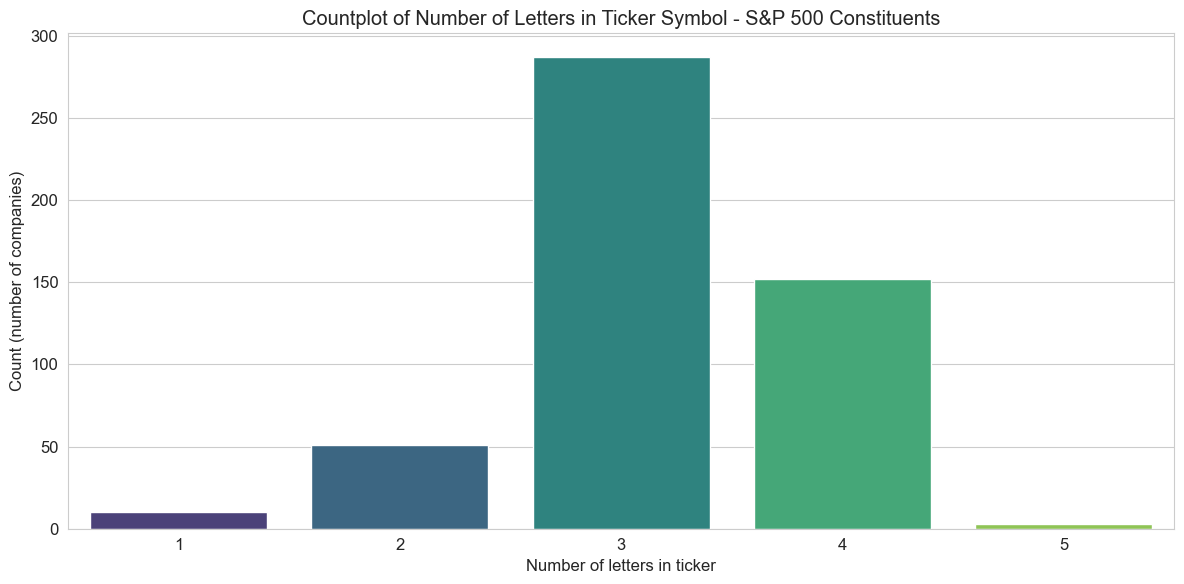

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
df['Symbol_Length'] = df['Symbol'].str.len()
sns.countplot(data=df, x="Symbol_Length", palette="viridis", ax=ax)
ax.set_xlabel("Number of letters in ticker")
ax.set_ylabel("Count (number of companies)")
ax.set_title("Countplot of Number of Letters in Ticker Symbol - S&P 500 Constituents")
plt.tight_layout()
plt.show()

### Insight 3 (r3): Grouped Sectors into Macro Categories

**Insight:** When sectors are grouped into macro categories (Technology, Health, Financials, Consumer, Industrial & Other), Technology leads with Health in second. Communication and Real Estate are the least commonly found. 

**Analysis type:** Univariate, categorical - grouped-data countplot (grouping explained below).

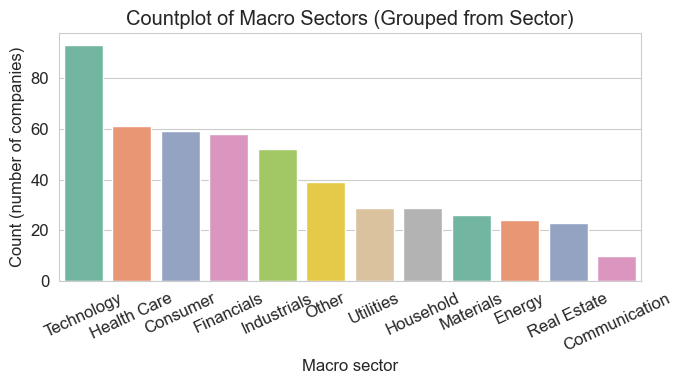

In [36]:
def map_sector(s):
    s_lower = str(s).lower()

    if any(k in s_lower for k in [
        "software", "it ", "semiconductor", "technology",
        "data processing", "internet services",
        "electronic", "communications equipment",
        "systems software", "application software",
        "technology hardware", "semiconductor materials",
        "interactive media", "transaction & payment processing"
    ]):
        return "Technology"

    if any(k in s_lower for k in [
        "health", "biotechnology", "pharmaceutical",
        "life sciences", "health care", "medical",
        "managed health", "health care equipment",
        "health care services", "health care supplies"
    ]):
        return "Health Care"

    if any(k in s_lower for k in [
        "bank", "insurance", "financial",
        "asset management", "investment banking",
        "capital markets", "consumer finance",
        "reinsurance", "brokerage", "exchanges"
    ]):
        return "Financials"

    if any(k in s_lower for k in [
        "retail", "automobile", "automotive",
        "hotels", "resorts", "casinos",
        "restaurants", "leisure",
        "apparel", "luxury", "footwear",
        "home improvement", "home furnishings",
        "movies", "entertainment"
    ]):
        return "Consumer"

    if any(k in s_lower for k in [
        "food", "beverages", "brewers",
        "distillers", "tobacco",
        "household products",
        "personal care",
        "packaged foods",
        "drug retail",
        "consumer staples"
    ]):
        return "Household"

    if any(k in s_lower for k in [
        "oil & gas", "energy",
        "exploration & production",
        "refining", "storage & transportation",
        "integrated oil", "oil & gas equipment"
    ]):
        return "Energy"

    if any(k in s_lower for k in [
        "electric utilities", "gas utilities",
        "water utilities", "multi-utilities",
        "independent power producers"
    ]):
        return "Utilities"

    if any(k in s_lower for k in [
        "reit", "real estate",
        "office reits", "data center reits",
        "industrial reits", "retail reits",
        "residential reits", "self-storage",
        "timber reits", "hotel & resort reits"
    ]):
        return "Real Estate"

    if any(k in s_lower for k in [
        "chemicals", "specialty chemicals",
        "commodity chemicals",
        "metals", "steel", "copper",
        "gold", "paper", "plastic",
        "containers", "construction materials",
        "fertilizers", "agricultural chemicals"
    ]):
        return "Materials"

    if any(k in s_lower for k in [
        "industrial", "machinery",
        "aerospace", "defense",
        "construction", "engineering",
        "transportation", "rail",
        "air freight", "logistics",
        "distributors", "trading companies",
        "environmental services"
    ]):
        return "Industrials"

    if any(k in s_lower for k in [
        "telecommunication", "wireless",
        "cable", "satellite",
        "broadcasting", "publishing",
        "interactive home entertainment"
    ]):
        return "Communication"

    return "Other"

df["MacroSector"] = df["Sector"].apply(map_sector)

fig, ax = plt.subplots(figsize=(7, 4))
order = df["MacroSector"].value_counts().index
sns.countplot(data=df, x="MacroSector", order=order, ax=ax, palette="Set2")
ax.set_xlabel("Macro sector")
ax.set_ylabel("Count (number of companies)")
ax.set_title("Countplot of Macro Sectors (Grouped from Sector)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Insight 4 (r4): Boxplot of Price/Earnings by Macro Sector

**Insight:** P/E ratios differ by macro sector, such as some sectors (e.g., technology) show higher median P/E and wider dispersion than others. On the other hand, sectors such as Utilities are all in a tight range in terms of P/E ratio.

**Analysis type:** Bivariate, numerical/categorical - numerical variable (Price/Earnings) distribution by categorical (Macro Sector).

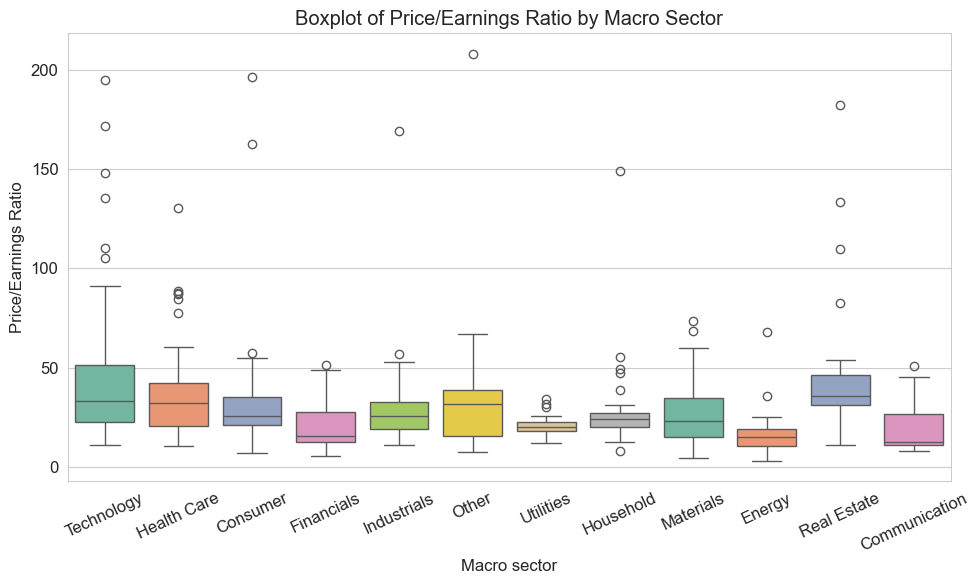

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
order = df["MacroSector"].value_counts().index

# For visualization purposes, we remove outliers beyond 3 standard deviations
mean_pe = df["Price/Earnings"].mean()
std_pe = df["Price/Earnings"].std()
df["pe_clean"] = df["Price/Earnings"].where(
    (df["Price/Earnings"] > mean_pe - 3 * std_pe) &
    (df["Price/Earnings"] < mean_pe + 3 * std_pe)
)

sns.boxplot(data=df, x="MacroSector", y="pe_clean", order=order, ax=ax, palette="Set2")
ax.set_xlabel("Macro sector")
ax.set_ylabel("Price/Earnings Ratio")
ax.set_title("Boxplot of Price/Earnings Ratio by Macro Sector")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Insight 5 (r5): Dividend-Paying vs Non-Paying (Binary)

**Insight:** Though most of the S&P 500 companies pay a dividend, almost half of Consumer and Technology companies don't pay a dividend.

**Analysis type:** Bivariate, categorical/categorical - comparing two categories (sector vs dividend yield).

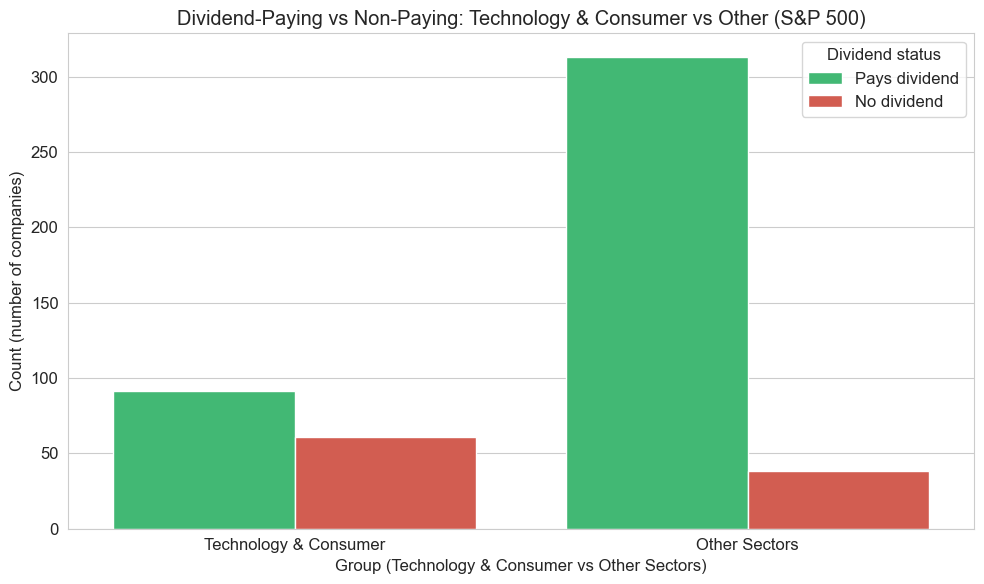

In [45]:
# Combine Technology and Consumer macro sectors vs all others, and compare dividend-paying status
def group_tech_consumer(macro_sector):
    if "Tech" in macro_sector or "Consumer" in macro_sector:
        return "Technology & Consumer"
    else:
        return "Other Sectors"

df["SectorGroup"] = df["MacroSector"].apply(group_tech_consumer)
df["DividendPayer"] = df["Dividend Yield"].apply(lambda x: "Pays dividend" if x > 0 else "No dividend")

sector_order = ["Technology & Consumer", "Other Sectors"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(
    data=df,
    x="SectorGroup",
    hue="DividendPayer",
    order=sector_order,
    palette=["#2ecc71", "#e74c3c"]
)
ax.set_ylabel("Count (number of companies)")
ax.set_xlabel("Group (Technology & Consumer vs Other Sectors)")
ax.set_title("Dividend-Paying vs Non-Paying: Technology & Consumer vs Other (S&P 500)")
ax.legend(title="Dividend status", loc="best")
plt.tight_layout()
plt.show()

### Insight 6 (r6): Ordered Countplot of Macro Sector by Symbol Length

**Insight:** Ordering macro sectors by total count and breaking down by ticker symbol length shows how the Technology sector prefer 4 letter ticker lengths while most sectors prefer 3 letter ticket lengths. 

**Analysis type:** Bivariate, categorical - countplot by sector and explicit order (by count), with a second categorical (symbol length) as hue.

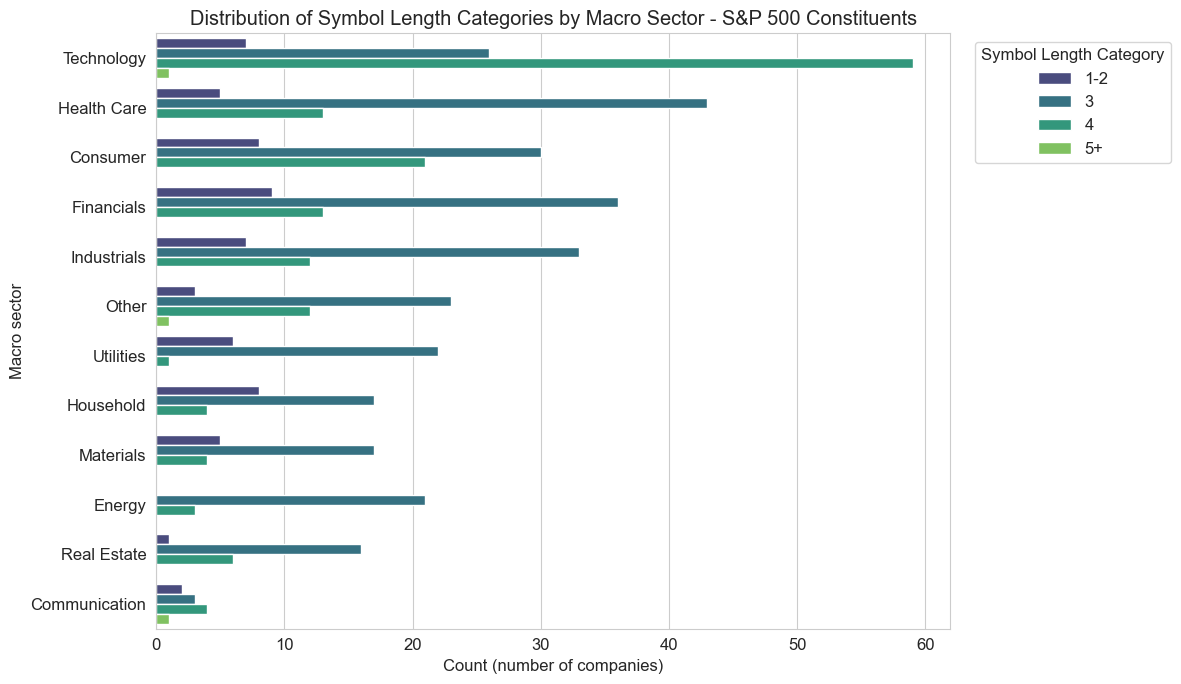

In [39]:
symbol_length = df["Symbol"].str.len()
bin_labels = ["1-2", "3", "4", "5+"]
df["SymbolLengthCat"] = pd.cut(symbol_length, bins=[0, 2, 3, 4, 99], labels=bin_labels, right=True, include_lowest=True)

macro_order = df["MacroSector"].value_counts().index
length_order = bin_labels

fig, ax = plt.subplots(figsize=(12, 7))
sns.countplot(
    data=df,
    y="MacroSector",
    hue="SymbolLengthCat",
    order=macro_order,
    hue_order=length_order,
    palette="viridis"
)
ax.set_xlabel("Count (number of companies)")
ax.set_ylabel("Macro sector")
ax.set_title("Distribution of Symbol Length Categories by Macro Sector - S&P 500 Constituents")
ax.legend(title="Symbol Length Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Insight 7 (r7): Sector Distribution by Market Cap Bins

**Insight:** Sector composition varies across market-cap size bins, larger-cap bins are comprised of sectors such as technology with some sectors not having a company with a market cap over 500B+ (e.g., Energy).

**Analysis type:** Bivariate, categorical/numerical - categorical (Sector) distribution among bins of a numerical feature (Market Cap).

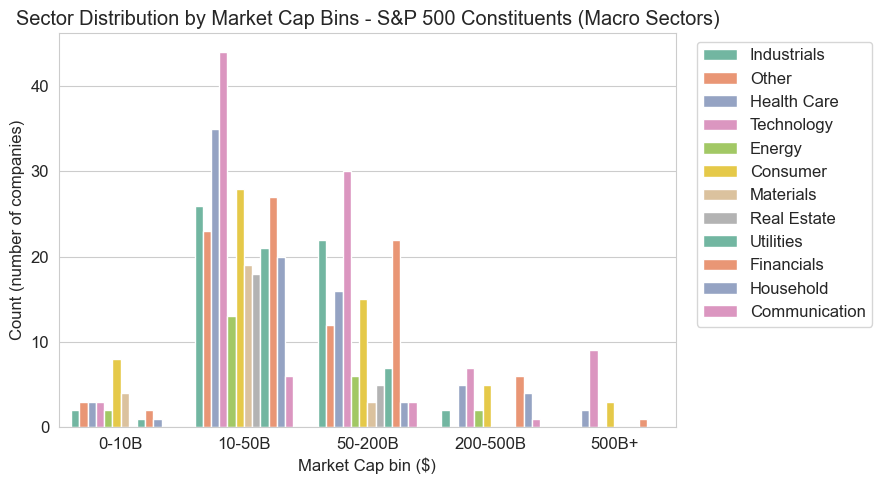

In [40]:
bins = [0, 10e9, 50e9, 200e9, 500e9, float("inf")]
labels = ["0-10B", "10-50B", "50-200B", "200-500B", "500B+"]
df["MarketCapBin"] = pd.cut(df["Market Cap"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x="MarketCapBin", hue="MacroSector", ax=ax, palette="Set2")
ax.set_xlabel("Market Cap bin ($)")
ax.set_ylabel("Count (number of companies)")
ax.set_title("Sector Distribution by Market Cap Bins - S&P 500 Constituents (Macro Sectors)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Insight 8 (r8): Scatterplot: Market Cap vs EBITDA

**Insight:** Market Cap and EBITDA are positively correlated; larger companies tend to have both higher market cap and higher EBITDA.

**Analysis type:** Bivariate, numerical/numerical - scatterplot to highlight correlation.

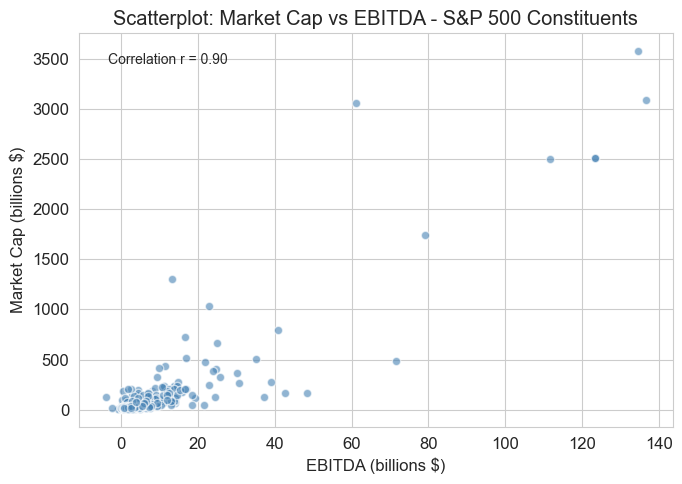

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["EBITDA"] / 1e9, df["Market Cap"] / 1e9, alpha=0.6, c="steelblue", edgecolors="white")
ax.set_xlabel("EBITDA (billions $)")
ax.set_ylabel("Market Cap (billions $)")
ax.set_title("Scatterplot: Market Cap vs EBITDA - S&P 500 Constituents")

r = df[["Market Cap", "EBITDA"]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f"Correlation r = {r:.2f}", transform=ax.transAxes, fontsize=10, verticalalignment="top")
plt.tight_layout()
plt.show()

### Insight 9 - Dividend Yield by Macro Sector (Paying Companies)

**Insight:** Among dividend payers, median dividend yield varies by macro sector; some sectors show higher yields (e.g., Utilities) compared to sectors such as technology which have lower average yields.

**Analysis type:** Bivariate, numerical/categorical - boxplot of Dividend Yield (%) by Macro Sector for companies that pay a dividend.

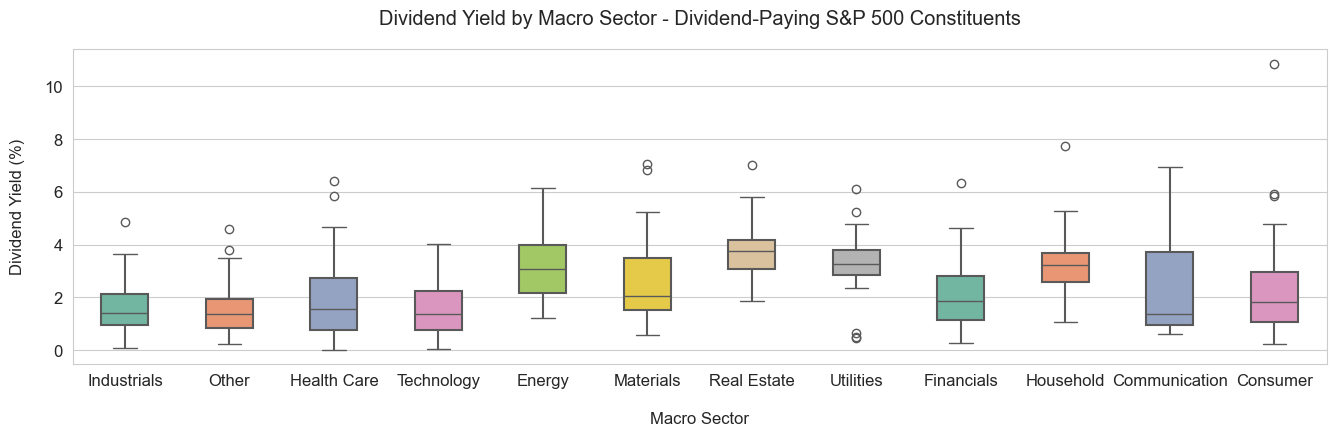

In [42]:
df["Dividend Yield (%)"] = df["Dividend Yield"] * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=df[df["Dividend Yield"] > 0],
    x="MacroSector",
    y="Dividend Yield (%)",
    ax=ax,
    palette="Set2",
    width=0.45,
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
)
ax.set_xlabel("Macro Sector", labelpad=16)
ax.set_ylabel("Dividend Yield (%)", labelpad=14)
ax.set_title("Dividend Yield by Macro Sector - Dividend-Paying S&P 500 Constituents", pad=18)
plt.tight_layout(pad=2.5)
plt.show()

### Insight 10 - 52-Week Volatility Across Macro Sectors

**Insight:** 52-week volatility (measured as (52 Week High - 52 Week Low) / Price) varies significantly across macro sectors. Some sectors, such as Technology and Communication Services, tend to exhibit a wider range and higher median volatility, while others like Utilities and Consumer Staples generally show lower volatility.

**Analysis type:** Bivariate, numerical/categorical - boxplot of 52-week volatility by Macro Sector (filtered to exclude extreme outliers).

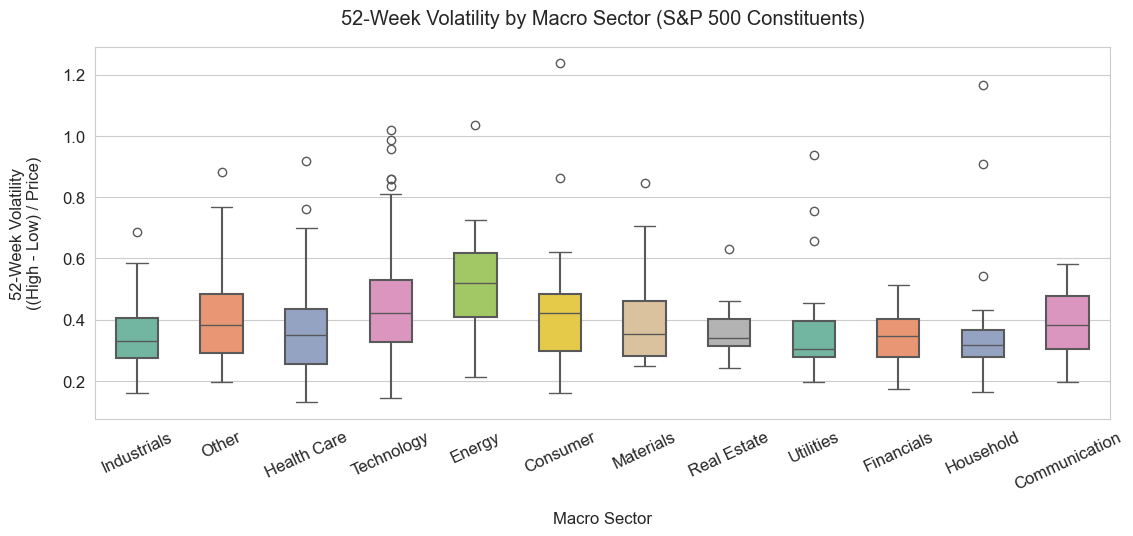

In [ ]:
# Calculate 52-week volatility as (52 Week High - 52 Week Low) / Price
df["Volatility"] = (df["52 Week High"] - df["52 Week Low"]) / df["Price"]
vol_mean = df["Volatility"].mean()
vol_std = df["Volatility"].std()

vol_mask = (df["Volatility"] >= vol_mean - 3 * vol_std) & (df["Volatility"] <= vol_mean + 3 * vol_std)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df[vol_mask],
    x="MacroSector",
    y="Volatility",
    ax=ax,
    palette="Set2",
    width=0.5,
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
)
ax.set_xlabel("Macro Sector", labelpad=14)
ax.set_ylabel("52-Week Volatility\n((High - Low) / Price)", labelpad=14)
ax.set_title("52-Week Volatility by Macro Sector (S&P 500 Constituents)", pad=16)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout(pad=2.5)
plt.show()

---
## 9. Conclusion

This exploratory data analysis examined two datasets from different domains to uncover meaningful insights through statistical analysis and visualization.

**Key Findings from Dataset 1 (Heart Failure Prediction):**

1. **Demographics:** The patient population is predominantly middle-aged to elderly (mean age ~54 years), with males comprising the majority and showing significantly higher heart disease rates (63% vs 26% in females).

2. **Strong Predictors:** Exercise-induced angina and ST slope pattern emerged as the strongest categorical predictors, with exercise angina patients showing 85% heart disease rate and flat ST slope patients showing 83% rate.

3. **Clinical Measurements:** Maximum heart rate showed clear differentiation between outcomes, with heart disease patients averaging 130 bpm compared to 158 bpm in healthy patients. A moderate negative correlation exists between MaxHR and Oldpeak.

4. **Risk Factors:** Over 40% of patients had high cholesterol levels (>=240 mg/dl), and heart disease prevalence increased substantially with age, from 25% in young patients to 67% in elderly patients.

5. **Data Quality:** The dataset is largely complete, though some cholesterol and blood pressure values of 0 likely represent unmeasured/missing data rather than actual values.

**Key Findings from Dataset 2 (S&P 500 Constituents Financials):**

1. **Sector Composition:** Technology and Health Care together account for a large share of S&P 500 constituents when grouped into macro categories.

2. **Valuation Patterns:** P/E ratios are right-skewed with most companies having P/E between 10-30, and P/E varies significantly by sector with Technology showing higher median valuations.

3. **Dividend Behavior:** Most S&P 500 companies pay dividends, with  Utilities and showing the highest dividend yields among sectors while almost half of Technology and Consumer companies do not.

4. **Size and Profitability:** Market Cap and EBITDA are positively correlated, and sector composition varies across market cap bins with Technology dominating larger-cap segments.

5. **Volatility:** 52-week volatility varies by sector, with Technology and Communication showing higher volatility compared to defensive/safer sectors like Utilities.

6. **Ticker Length:** Most companies have a ticker length of 2-4 with 3 being the most common. The exception is with Technology which on average have more 4 letter tickers than any other sector. 

---
## 10. References

### Datasets
1. fedesoriano. (2021). Heart Failure Prediction Dataset. Kaggle. https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
2. S&P 500 Companies Financials. GitHub. https://github.com/datasets/s-and-p-500-companies-financials

### Libraries and Documentation
3. Pandas Development Team. (2024). pandas documentation. https://pandas.pydata.org/docs/
4. Matplotlib Development Team. (2024). Matplotlib documentation. https://matplotlib.org/stable/
5. Seaborn Development Team. (2024). Seaborn documentation. https://seaborn.pydata.org/

### Medical References
6. American Heart Association. (2024). Understanding Blood Pressure Readings. https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings
7. Centers for Disease Control and Prevention. (2024). Cholesterol Levels. https://www.cdc.gov/cholesterol/

### AI Assistance
1. **ChatGPT (OpenAI):** Used to design the sector-grouping approach for the univariate categorical grouped analysis (Dataset 2, Insight 3). Prompt: For a Univariate Categorical Grouped analysis with a function (`map_sector`) to group the dataset's many unique sectors into broader macro categories.